In this code I apply the state estimation algorithm implemented in `utils/state_estimation.py` to estimate the state of custom generated data of a simulation with a quad robot as in `examples/mjx_quad.py`.

### Imports and prerequisites

In [30]:
import numpy as np
from pathlib import Path
import utils.state_estimation
from utils.plot_data import *
from gym_quadruped.quadruped_env import QuadrupedEnv
import mujoco
from tqdm import tqdm
from rosbags.highlevel import AnyReader
from rosbags.typesys import get_typestore, Stores
from pathlib import Path
import numpy as np

### Loading data

In [31]:
dataset_path = Path.cwd().parent / "custom_datasets"
dataset = np.load(f"{dataset_path}/quad_dataset_run2.npz")
num_datasets = len(dataset["time"])
dataset_size = len(dataset["time"][0])

dt = dataset["dt"]
time = dataset["time"]
base_pos = dataset["base_pos"]
base_orient = dataset["base_orient"]
base_vel = dataset["base_vel"]
base_ang_vel = dataset["base_ang_vel"]
base_acc = dataset["base_acc"]
joint_pos = dataset["joint_pos"]
joint_vel = dataset["joint_vel"]
joint_acc = dataset["joint_acc"]
joint_torque = dataset["joint_torque"]
contact_states = dataset["contact_states"]
contact_pos = dataset["contact_pos"]
contact_forces = dataset["contact_forces"]
contact_pos_des = dataset["contact_pos_des"]

In [32]:
print(base_pos[0][0].shape)
print(base_orient[0][0].shape)
print(base_acc[0][0].shape)
print(base_ang_vel[0][0].shape)
print(joint_pos[0][0].shape)
print(joint_vel[0][0].shape)
print(contact_states[0][0].shape)
print(contact_forces[0][0].shape)
print(contact_pos[0][0].shape)

(3,)
(4,)
(3,)
(3,)
(12,)
(12,)
(4,)
(4, 3)
(4, 3)


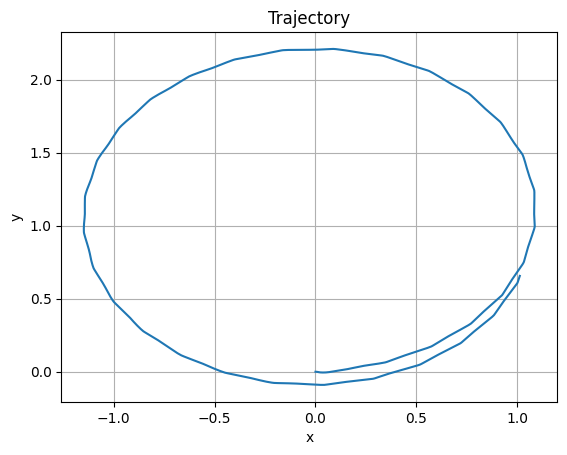

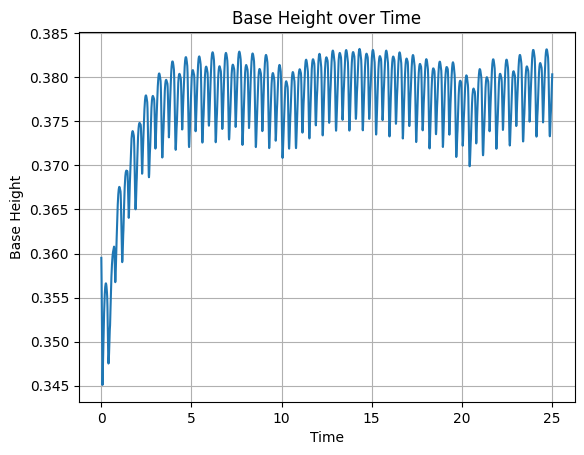

In [33]:
base_pos = dataset["base_pos"]
time = dataset["time"]
base_plot(time[0], base_pos[0])

## State Estimation

### With measured base acceleration

In [34]:
# results of EKF prediction step
pos_predict = []
P_predict = []
vel_precict = []

# results of leg odometryy
leg_odom = []

# results of EKF update step
pos_update = []
P_update = []
vel_update = []

for j in range(num_datasets):
    sim_num = j
    print(20*"=", f"Simulation no. {sim_num+1}", 20*"=")

    #nv = base_vel[sim_num][0].size + base_ang_vel[sim_num][0].size + joint_vel[sim_num][0].size
    Q_diag = 0.0002
    R_diag = 0.01
    ekf = utils.state_estimation.EKF(init_pos=base_pos[sim_num][0], dt=dt[sim_num][0], Q_diag=Q_diag, R_diag=R_diag)

    pos_predict_sim = []
    vel_precict_sim = []
    P_predict_sim = []

    leg_odom_sim = []

    pos_update_sim = []
    vel_update_sim = []
    P_update_sim = []

    for i in tqdm(range(dataset_size), desc="Estimating state"):
        ekf.step(base_orient=base_orient[sim_num][i],
                 base_acc=base_acc[sim_num][i], # prediction step with base acceleration as control input
                 base_ang_vel=base_ang_vel[sim_num][i],
                 joint_pos=joint_pos[sim_num][i],
                 joint_vel=joint_vel[sim_num][i],
                 contact_states=contact_states[sim_num][i],
                 contact_forces=contact_forces[sim_num][i],
                 contact_pos=contact_pos[sim_num][i])

        pos_predict_sim.append(ekf.x_pred[:3])
        P_predict_sim.append(ekf.P_pred)
        vel_precict_sim.append(ekf.x_pred[3:])

        leg_odom_sim.append(ekf.z)

        pos_update_sim.append(ekf.x[:3])
        vel_update_sim.append(ekf.x[3:])
        P_update_sim.append(ekf.P)
    
    pos_predict.append(pos_predict_sim)
    vel_precict.append(vel_precict_sim)
    P_predict.append(P_predict_sim)

    leg_odom.append(leg_odom_sim)

    pos_update.append(pos_update_sim)
    vel_update.append(vel_update_sim)
    P_update.append(P_update_sim)

    print()
    break

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


==================== Simulation no. 1 ====================


Estimating state: 100%|██████████| 5000/5000 [00:02<00:00, 2453.40it/s]

In [35]:
def compute_pos_from_estimated_vel(velocities, dt):
    positions = []
    prev_pos = np.zeros((3,))
    for vel in velocities:
        next_pos = prev_pos + dt * vel
        positions.append(next_pos)
        prev_pos = next_pos
    
    return positions

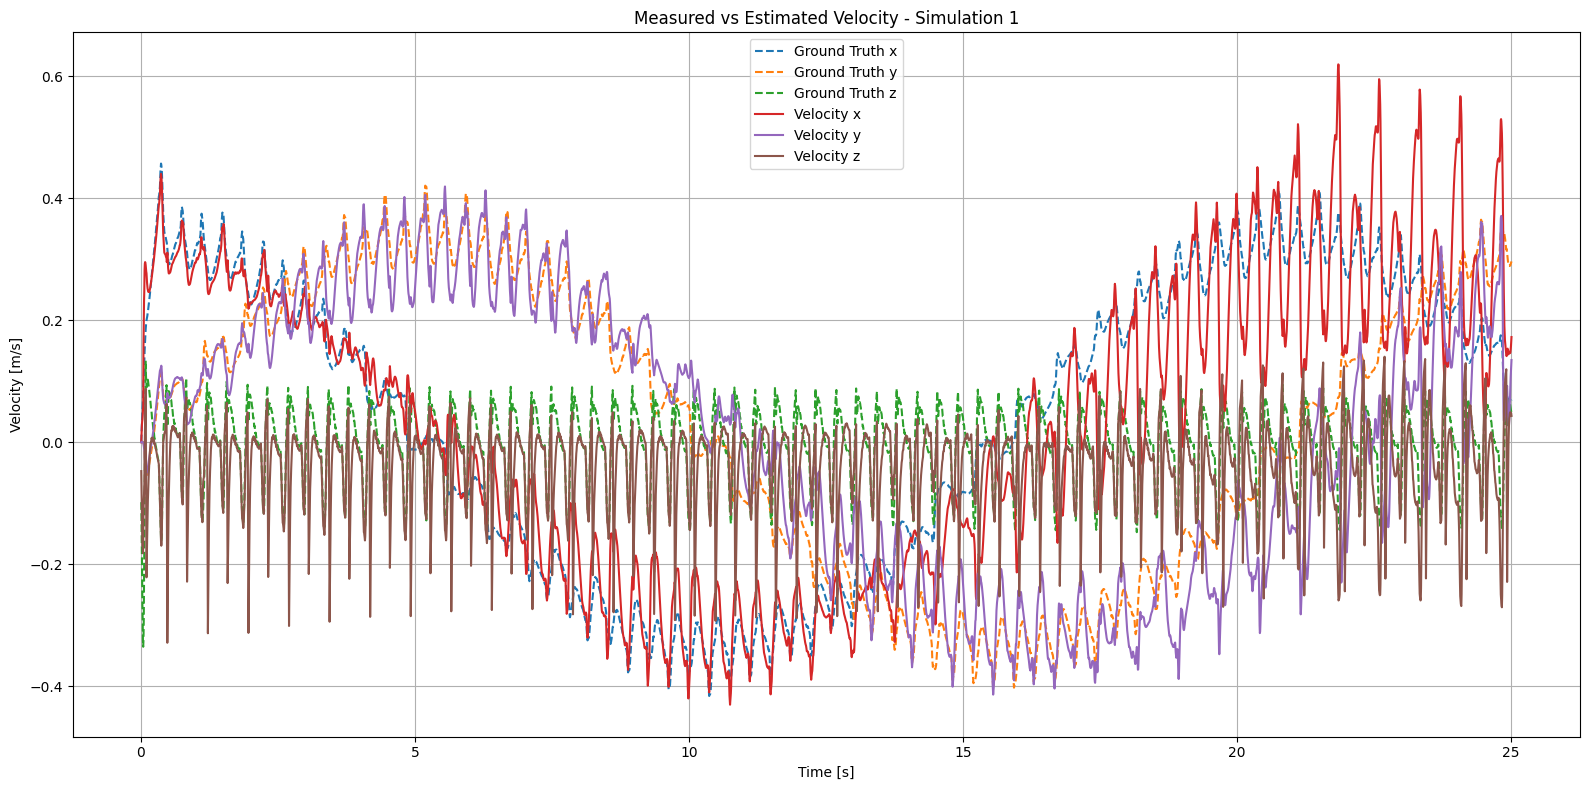

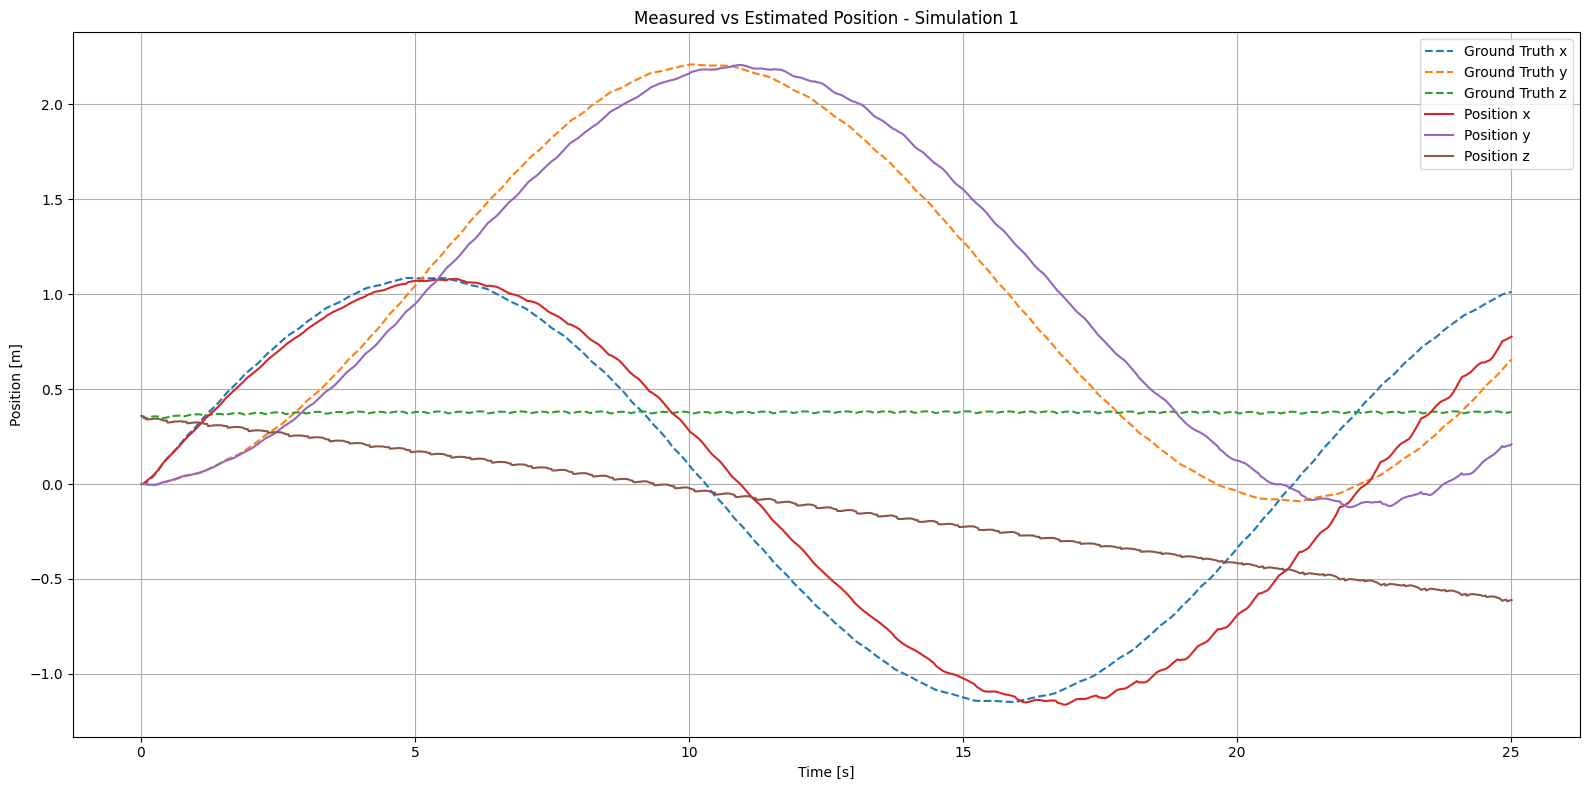

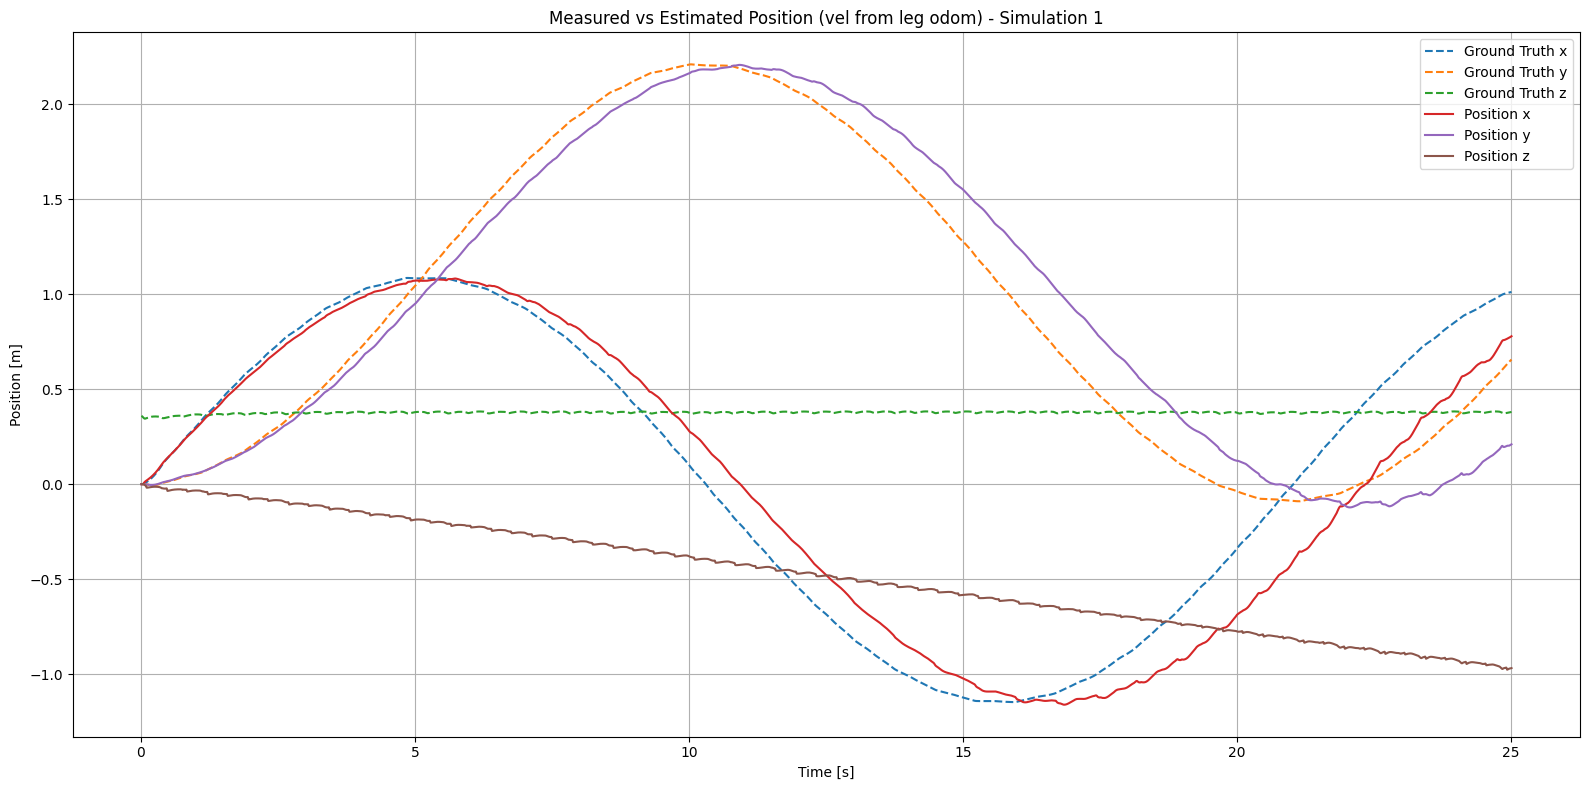

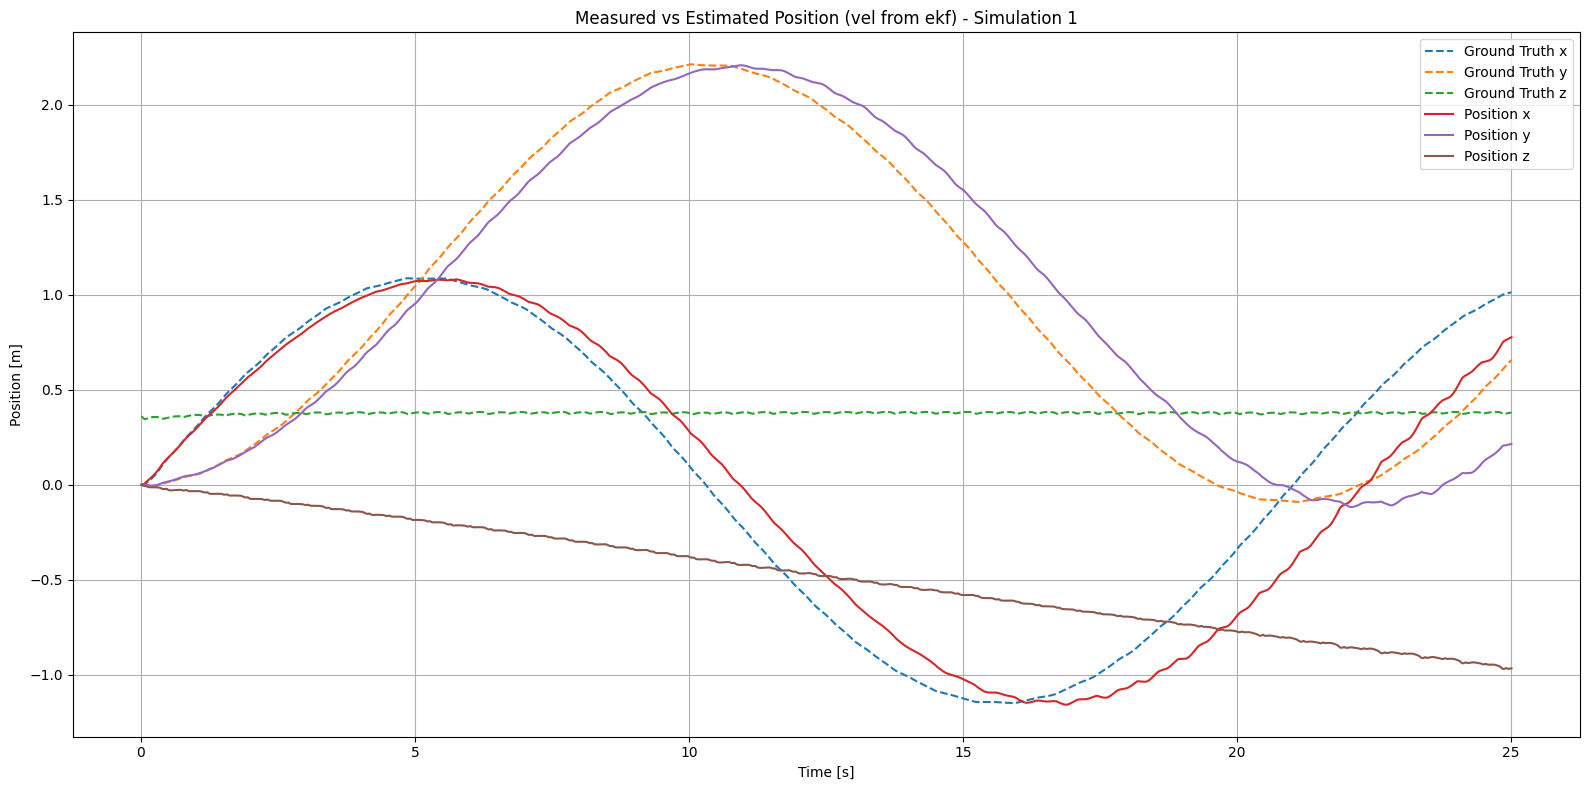

In [36]:
sim_num = 0

# --- Velocity ---
compare_estimation_plot(time=time[sim_num],
                        gt_values=base_vel[sim_num],
                        pred_values=[np.array(vel_update[sim_num])],
                        pred_labels=["Velocity"],
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity - Simulation {sim_num+1}",
                        combined_plot=True
                        )

# --- Position ---
compare_estimation_plot(time=time[sim_num],
                        gt_values=base_pos[sim_num],
                        pred_values=[np.array(pos_update[sim_num])],
                        pred_labels=["Position"],
                        ylabel="Position [m]",
                        title=f"Measured vs Estimated Position - Simulation {sim_num+1}"
                        )

# --- Position from leg odom velocity ---
integr_pos = compute_pos_from_estimated_vel(np.array(leg_odom[sim_num]), dt[sim_num][0])
compare_estimation_plot(time=time[sim_num],
                        gt_values=base_pos[sim_num],
                        pred_values=[np.array(integr_pos)],
                        pred_labels=["Position"],
                        ylabel="Position [m]",
                        title=f"Measured vs Estimated Position (vel from leg odom) - Simulation {sim_num+1}"
                        )

# --- Position from ekf velocity ---
integr_pos = compute_pos_from_estimated_vel(np.array(vel_update[sim_num]), dt[sim_num][0])
compare_estimation_plot(time=time[sim_num],
                        gt_values=base_pos[sim_num],
                        pred_values=[np.array(integr_pos)],
                        pred_labels=["Position"],
                        ylabel="Position [m]",
                        title=f"Measured vs Estimated Position (vel from ekf) - Simulation {sim_num+1}"
                        )

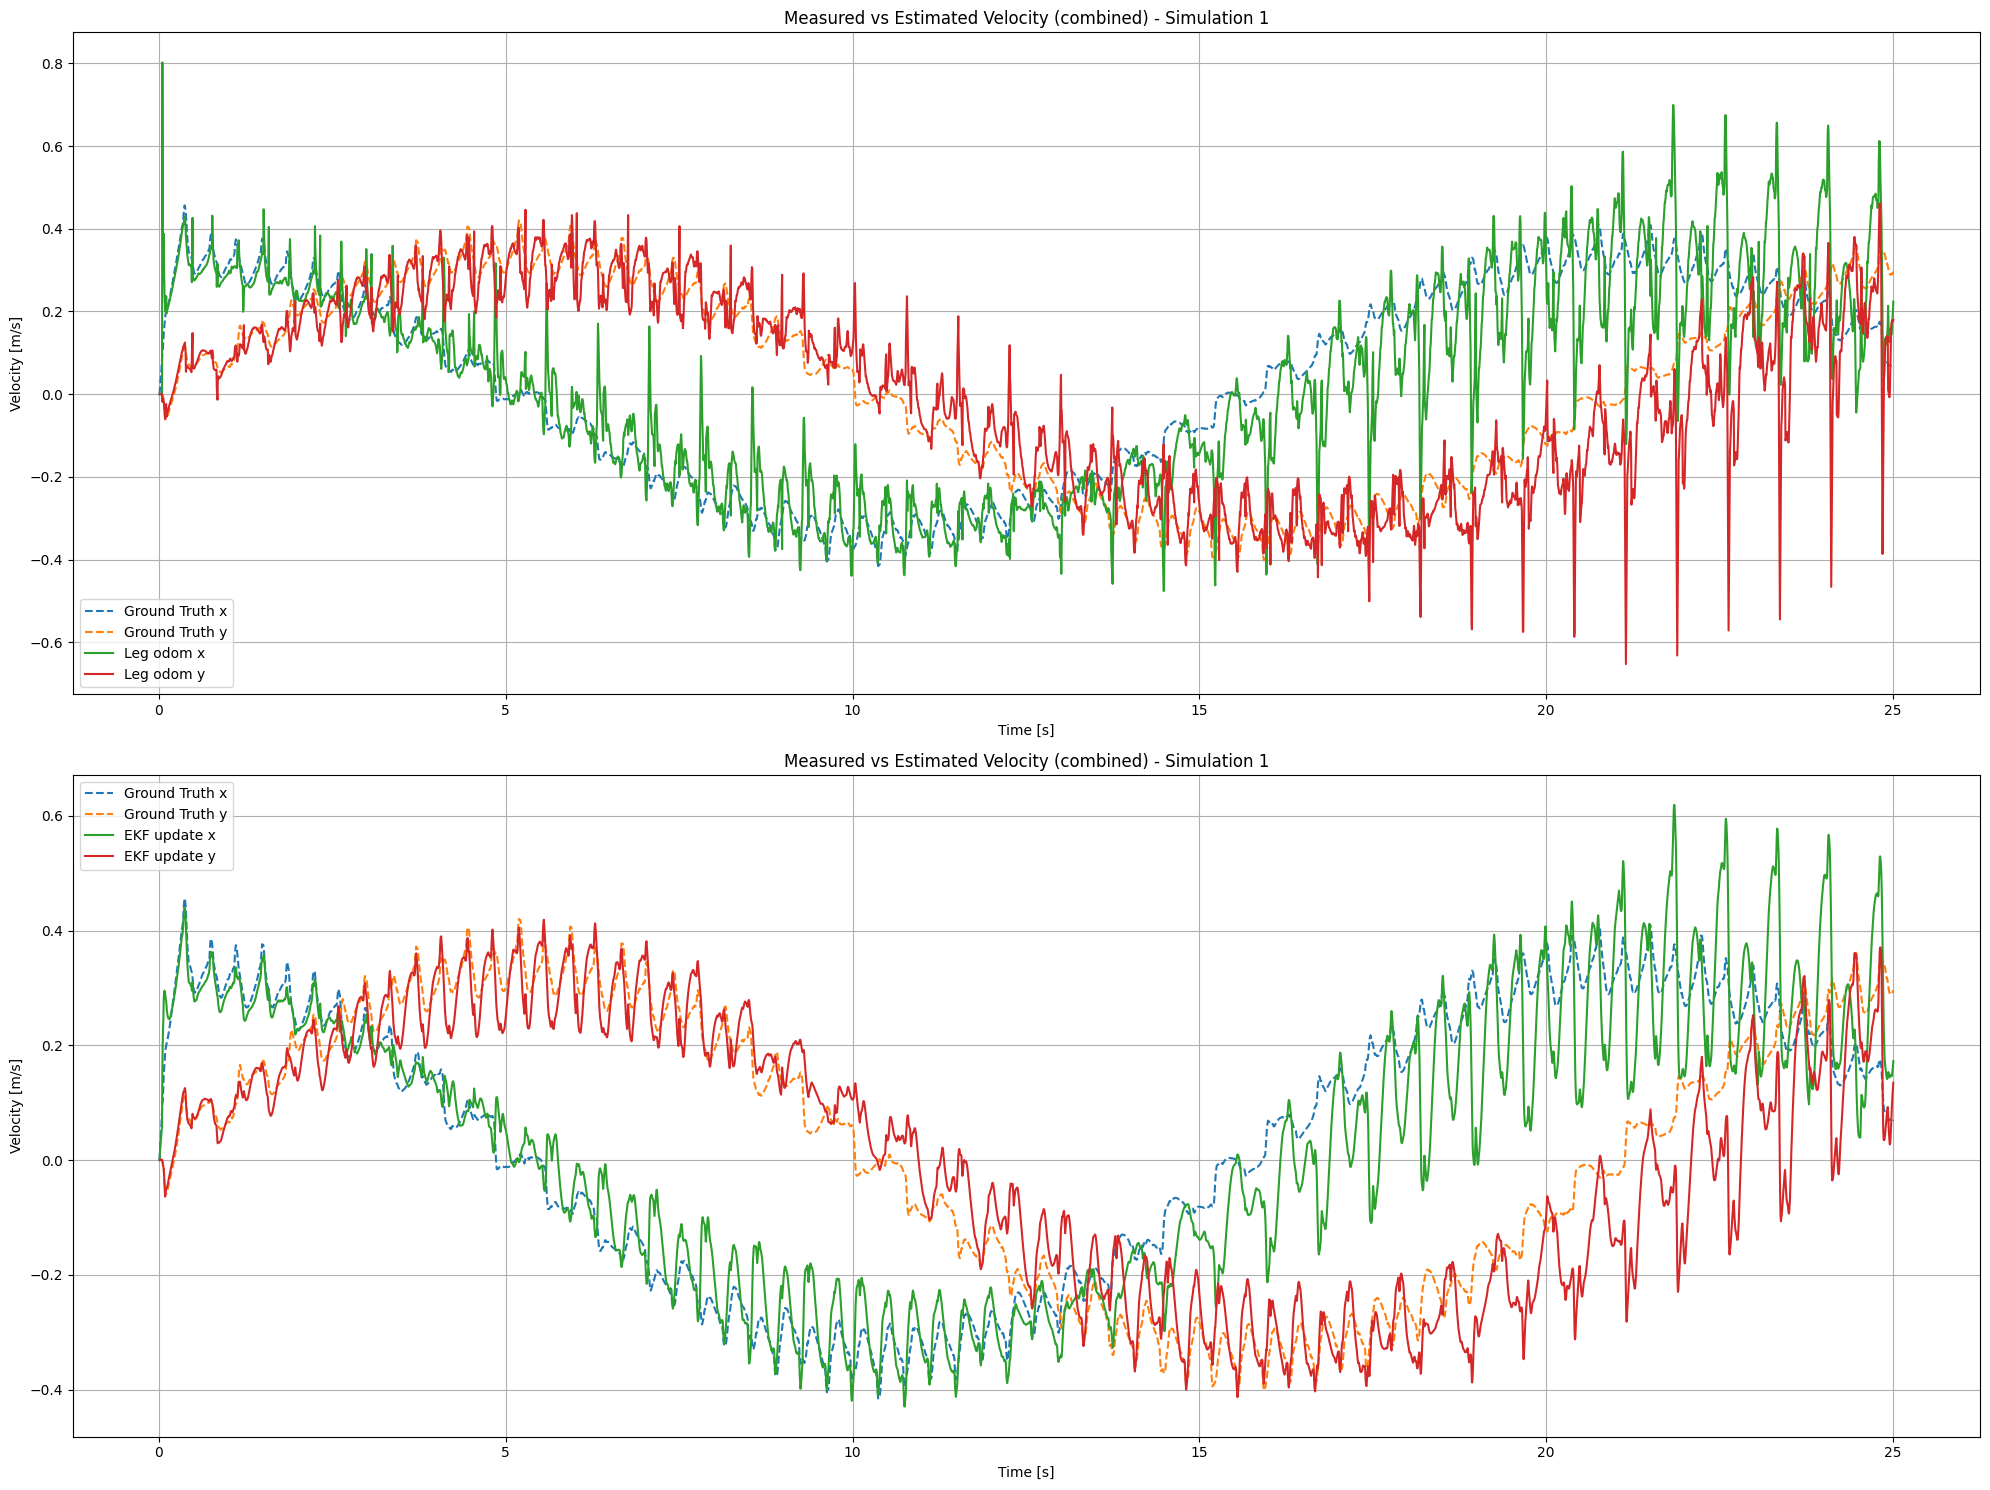

In [37]:
# --- Velocity leg odom, EKF and gt ---
predictions = [np.array(leg_odom)[sim_num][:, :2], np.array(vel_update[sim_num])[:, :2]]
pred_labels = ["Leg odom", "EKF update"]

compare_estimation_plot(time=time[sim_num],
                        gt_values=base_vel[sim_num][:, :2],
                        pred_values=predictions,
                        pred_labels=pred_labels,
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity (combined) - Simulation {sim_num+1}",
                        combined_plot=False
                        )

### With estimated acceleration from contact force

In [38]:
def estimate_acc_from_contact_force(env, contact_states, contact_forces):
    m = float(np.sum(env.mjModel.body_mass))
    g = 9.81
    Fg = m * np.array([0, 0, g])

    force = np.zeros((3,))

    # sum jacobians of all legs that are in contact
    for i in range(4):
        c_i = contact_states[i]
        cf_i = contact_forces[i]

        force += c_i * cf_i

    acc = (force - Fg) / m

    return acc, force

In [41]:
# results of EKF prediction step
pos_predict = []
P_predict = []
vel_precict = []

# results of leg odometryy
leg_odom = []

# results of EKF update step
pos_update = []
P_update = []
vel_update = []

for j in range(num_datasets):
    sim_num = j
    print(20*"=", f"Simulation no. {sim_num+1}", 20*"=")

    Q_diag = 0.0002
    R_diag = 0.01
    ekf = utils.state_estimation.EKF(init_pos=base_pos[sim_num][0], dt=dt[sim_num][0], Q_diag=Q_diag, R_diag=R_diag)

    pos_predict_sim = []
    vel_precict_sim = []
    P_predict_sim = []

    leg_odom_sim = []

    pos_update_sim = []
    vel_update_sim = []
    P_update_sim = []

    for i in tqdm(range(dataset_size), desc="Estimating state"):
        acc, _ = estimate_acc_from_contact_force(env=ekf.leg_odom.env, 
                                                    contact_states=contact_states[sim_num][j], 
                                                    contact_forces=contact_forces[sim_num][i])

        ekf.step(base_orient=base_orient[sim_num][i],
                 base_acc=acc, # prediction step with estimated acc
                 base_ang_vel=base_ang_vel[sim_num][i],
                 joint_pos=joint_pos[sim_num][i],
                 joint_vel=joint_vel[sim_num][i],
                 contact_states=contact_states[sim_num][i],
                 contact_forces=contact_forces[sim_num][i],
                 contact_pos=contact_pos[sim_num][i])

        pos_predict_sim.append(ekf.x_pred[:3])
        P_predict_sim.append(ekf.P_pred)
        vel_precict_sim.append(ekf.x_pred[3:])

        leg_odom_sim.append(ekf.z)

        pos_update_sim.append(ekf.x[:3])
        vel_update_sim.append(ekf.x[3:])
        P_update_sim.append(ekf.P)
    
    pos_predict.append(pos_predict_sim)
    vel_precict.append(vel_precict_sim)
    P_predict.append(P_predict_sim)

    leg_odom.append(leg_odom_sim)

    pos_update.append(pos_update_sim)
    vel_update.append(vel_update_sim)
    P_update.append(P_update_sim)

    print()
    break

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


==================== Simulation no. 1 ====================


Estimating state: 100%|██████████| 5000/5000 [00:01<00:00, 2541.23it/s]

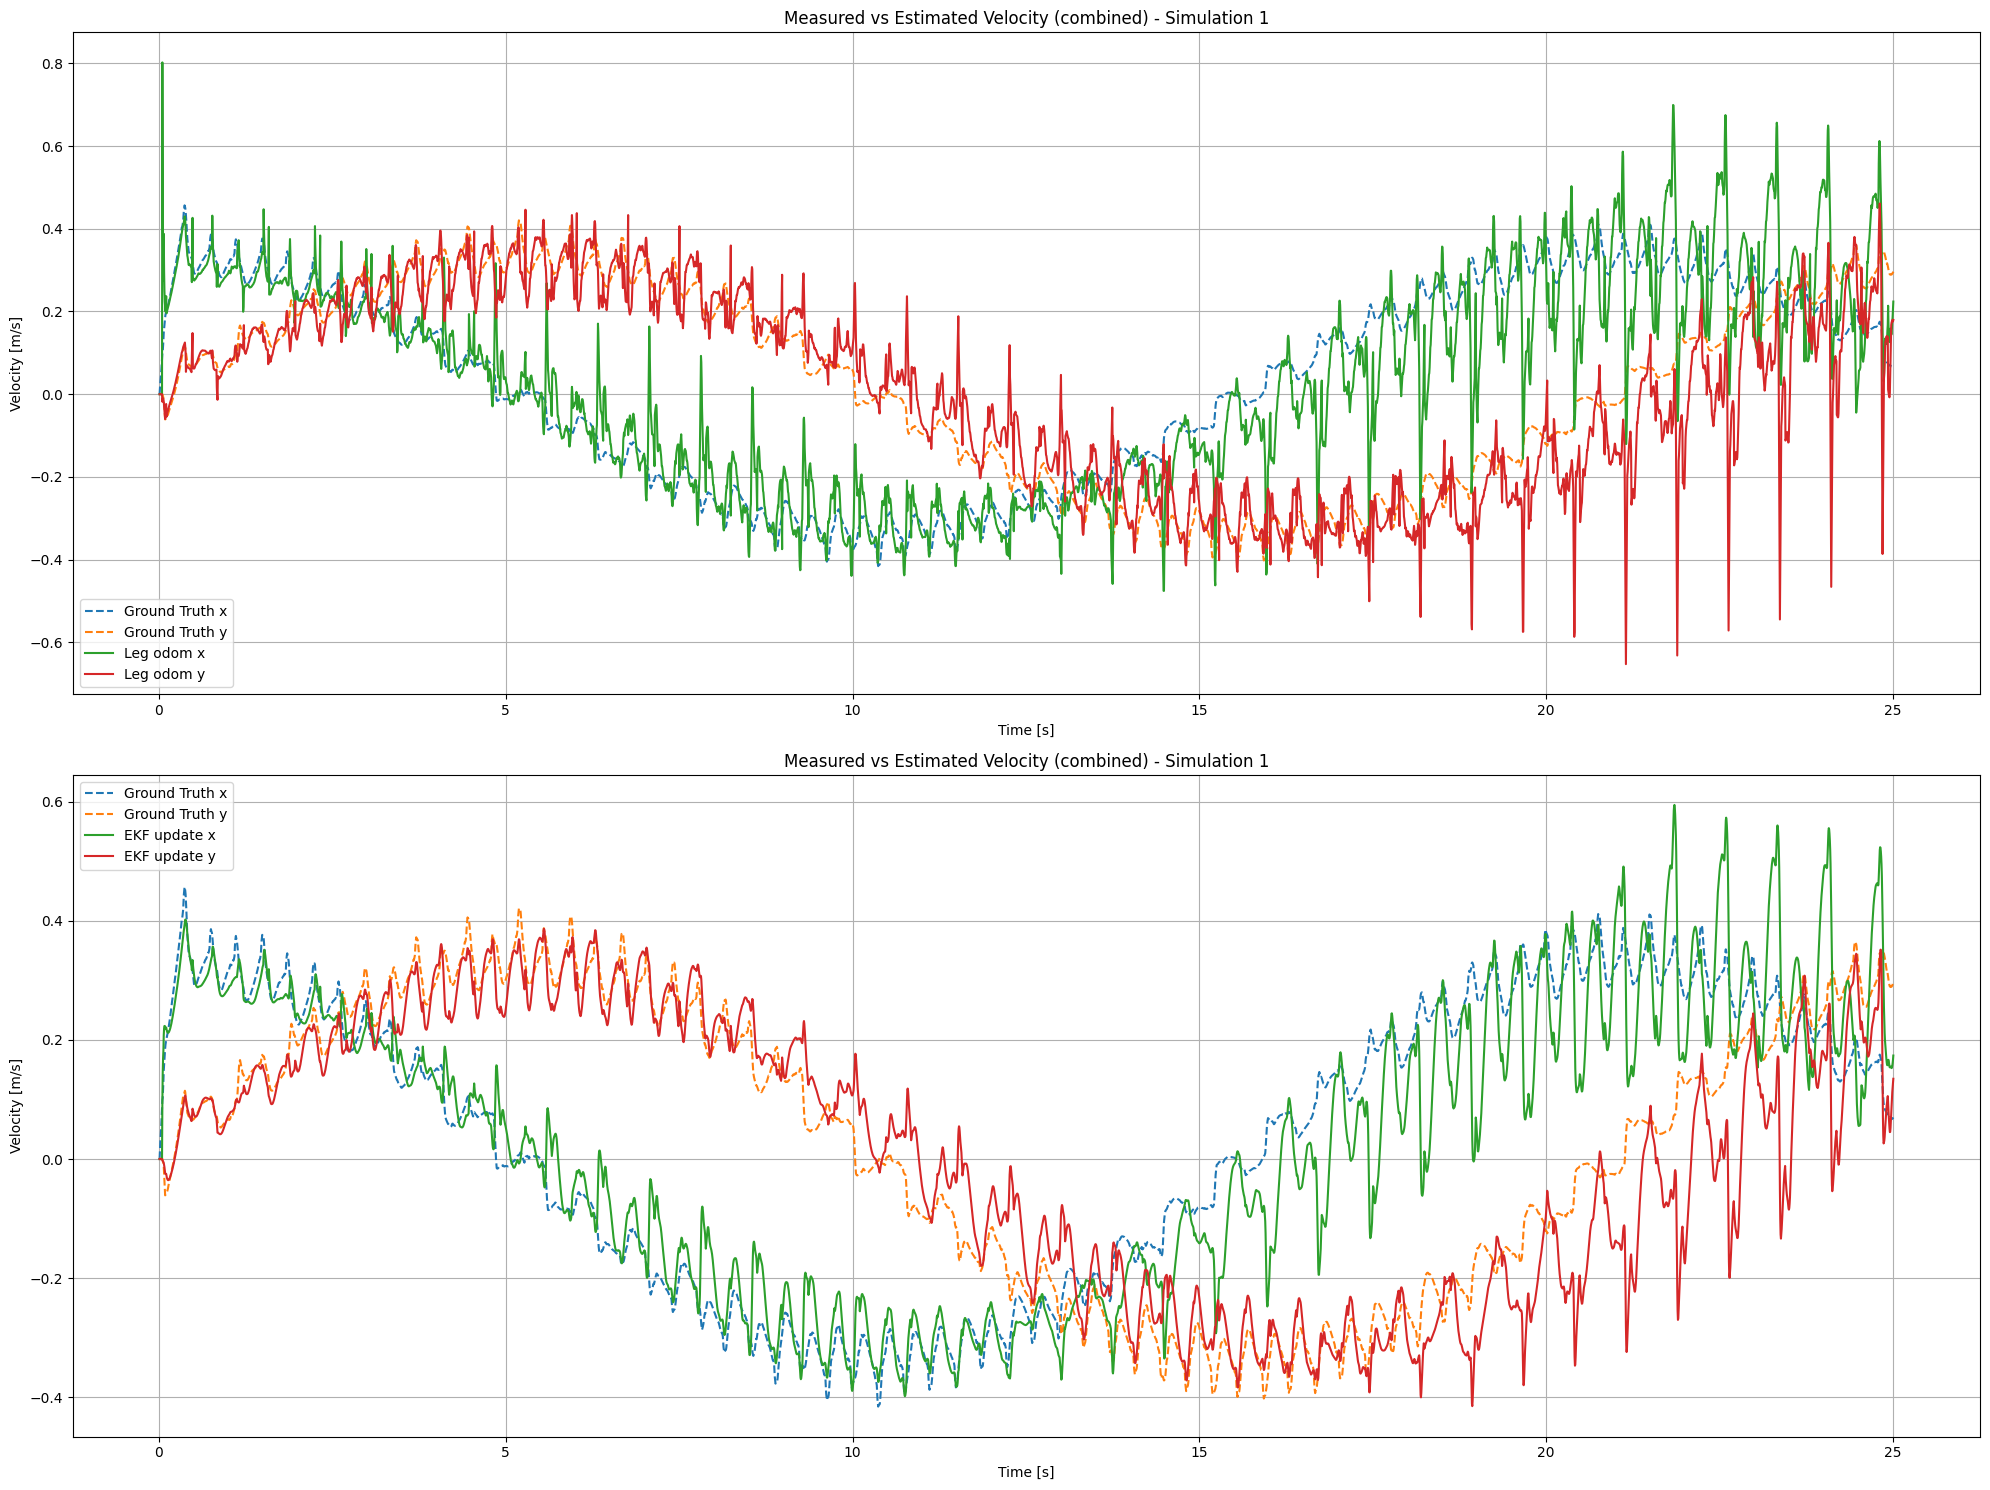

In [43]:
# --- Velocity leg odom, EKF and gt ---
predictions = [np.array(leg_odom)[sim_num][:, :2], np.array(vel_update[sim_num])[:, :2]]
pred_labels = ["Leg odom", "EKF update"]

compare_estimation_plot(time=time[sim_num],
                        gt_values=base_vel[sim_num][:, :2],
                        pred_values=predictions,
                        pred_labels=pred_labels,
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity (combined) - Simulation {sim_num+1}",
                        combined_plot=False
                        )

### With estimated acceleration from estimated contact force

In [44]:
def estimate_acc_from_estimated_contact_force(env, torque, contact_states):
    m = float(np.sum(env.mjModel.body_mass))
    g = 9.81
    Fg = m * np.array([0, 0, g])
    J_feet_linear = env.feet_jacobians(frame="world")

    force = np.zeros((3,))
    contact_forces = []

    # sum jacobians of all legs that are in contact
    for i in range(4):
        leg_name = env.legs_order[i]
        c_i = contact_states[i]

        J_lin = c_i * J_feet_linear[leg_name][:, 6:]
        force += J_lin @ torque
        contact_forces.append(force)

    acc = (force - Fg) / m

    return acc, force, contact_forces

In [47]:
# results of EKF prediction step
pos_predict = []
P_predict = []
vel_precict = []

# results of leg odometryy
leg_odom = []

# results of EKF update step
pos_update = []
P_update = []
vel_update = []

for j in range(num_datasets):
    sim_num = j
    print(20*"=", f"Simulation no. {sim_num+1}", 20*"=")

    Q_diag = 0.0002
    R_diag = 0.01
    ekf = utils.state_estimation.EKF(init_pos=base_pos[sim_num][0], dt=dt[sim_num][0], Q_diag=Q_diag, R_diag=R_diag)

    pos_predict_sim = []
    vel_precict_sim = []
    P_predict_sim = []

    leg_odom_sim = []

    pos_update_sim = []
    vel_update_sim = []
    P_update_sim = []

    for i in tqdm(range(dataset_size), desc="Estimating state"):
        estimated_acc, _, estimated_contact_forces = estimate_acc_from_estimated_contact_force(env=ekf.leg_odom.env, 
                                                              torque=joint_torque[sim_num][i], 
                                                              contact_states=contact_states[sim_num][i])

        ekf.step(base_orient=base_orient[sim_num][i],
                 base_acc=estimated_acc, # prediction step with estimated acc
                 base_ang_vel=base_ang_vel[sim_num][i],
                 joint_pos=joint_pos[sim_num][i],
                 joint_vel=joint_vel[sim_num][i],
                 contact_states=contact_states[sim_num][i],
                 contact_forces=estimated_contact_forces,
                 contact_pos=contact_pos[sim_num][i])

        pos_predict_sim.append(ekf.x_pred[:3])
        P_predict_sim.append(ekf.P_pred)
        vel_precict_sim.append(ekf.x_pred[3:])

        leg_odom_sim.append(ekf.z)

        pos_update_sim.append(ekf.x[:3])
        vel_update_sim.append(ekf.x[3:])
        P_update_sim.append(ekf.P)
    
    pos_predict.append(pos_predict_sim)
    vel_precict.append(vel_precict_sim)
    P_predict.append(P_predict_sim)

    leg_odom.append(leg_odom_sim)

    pos_update.append(pos_update_sim)
    vel_update.append(vel_update_sim)
    P_update.append(P_update_sim)

    print()
    break

/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/undefined/miniconda3/envs/mpx_env/lib/python3.13/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


==================== Simulation no. 1 ====================


Estimating state: 100%|██████████| 5000/5000 [00:02<00:00, 1952.56it/s]

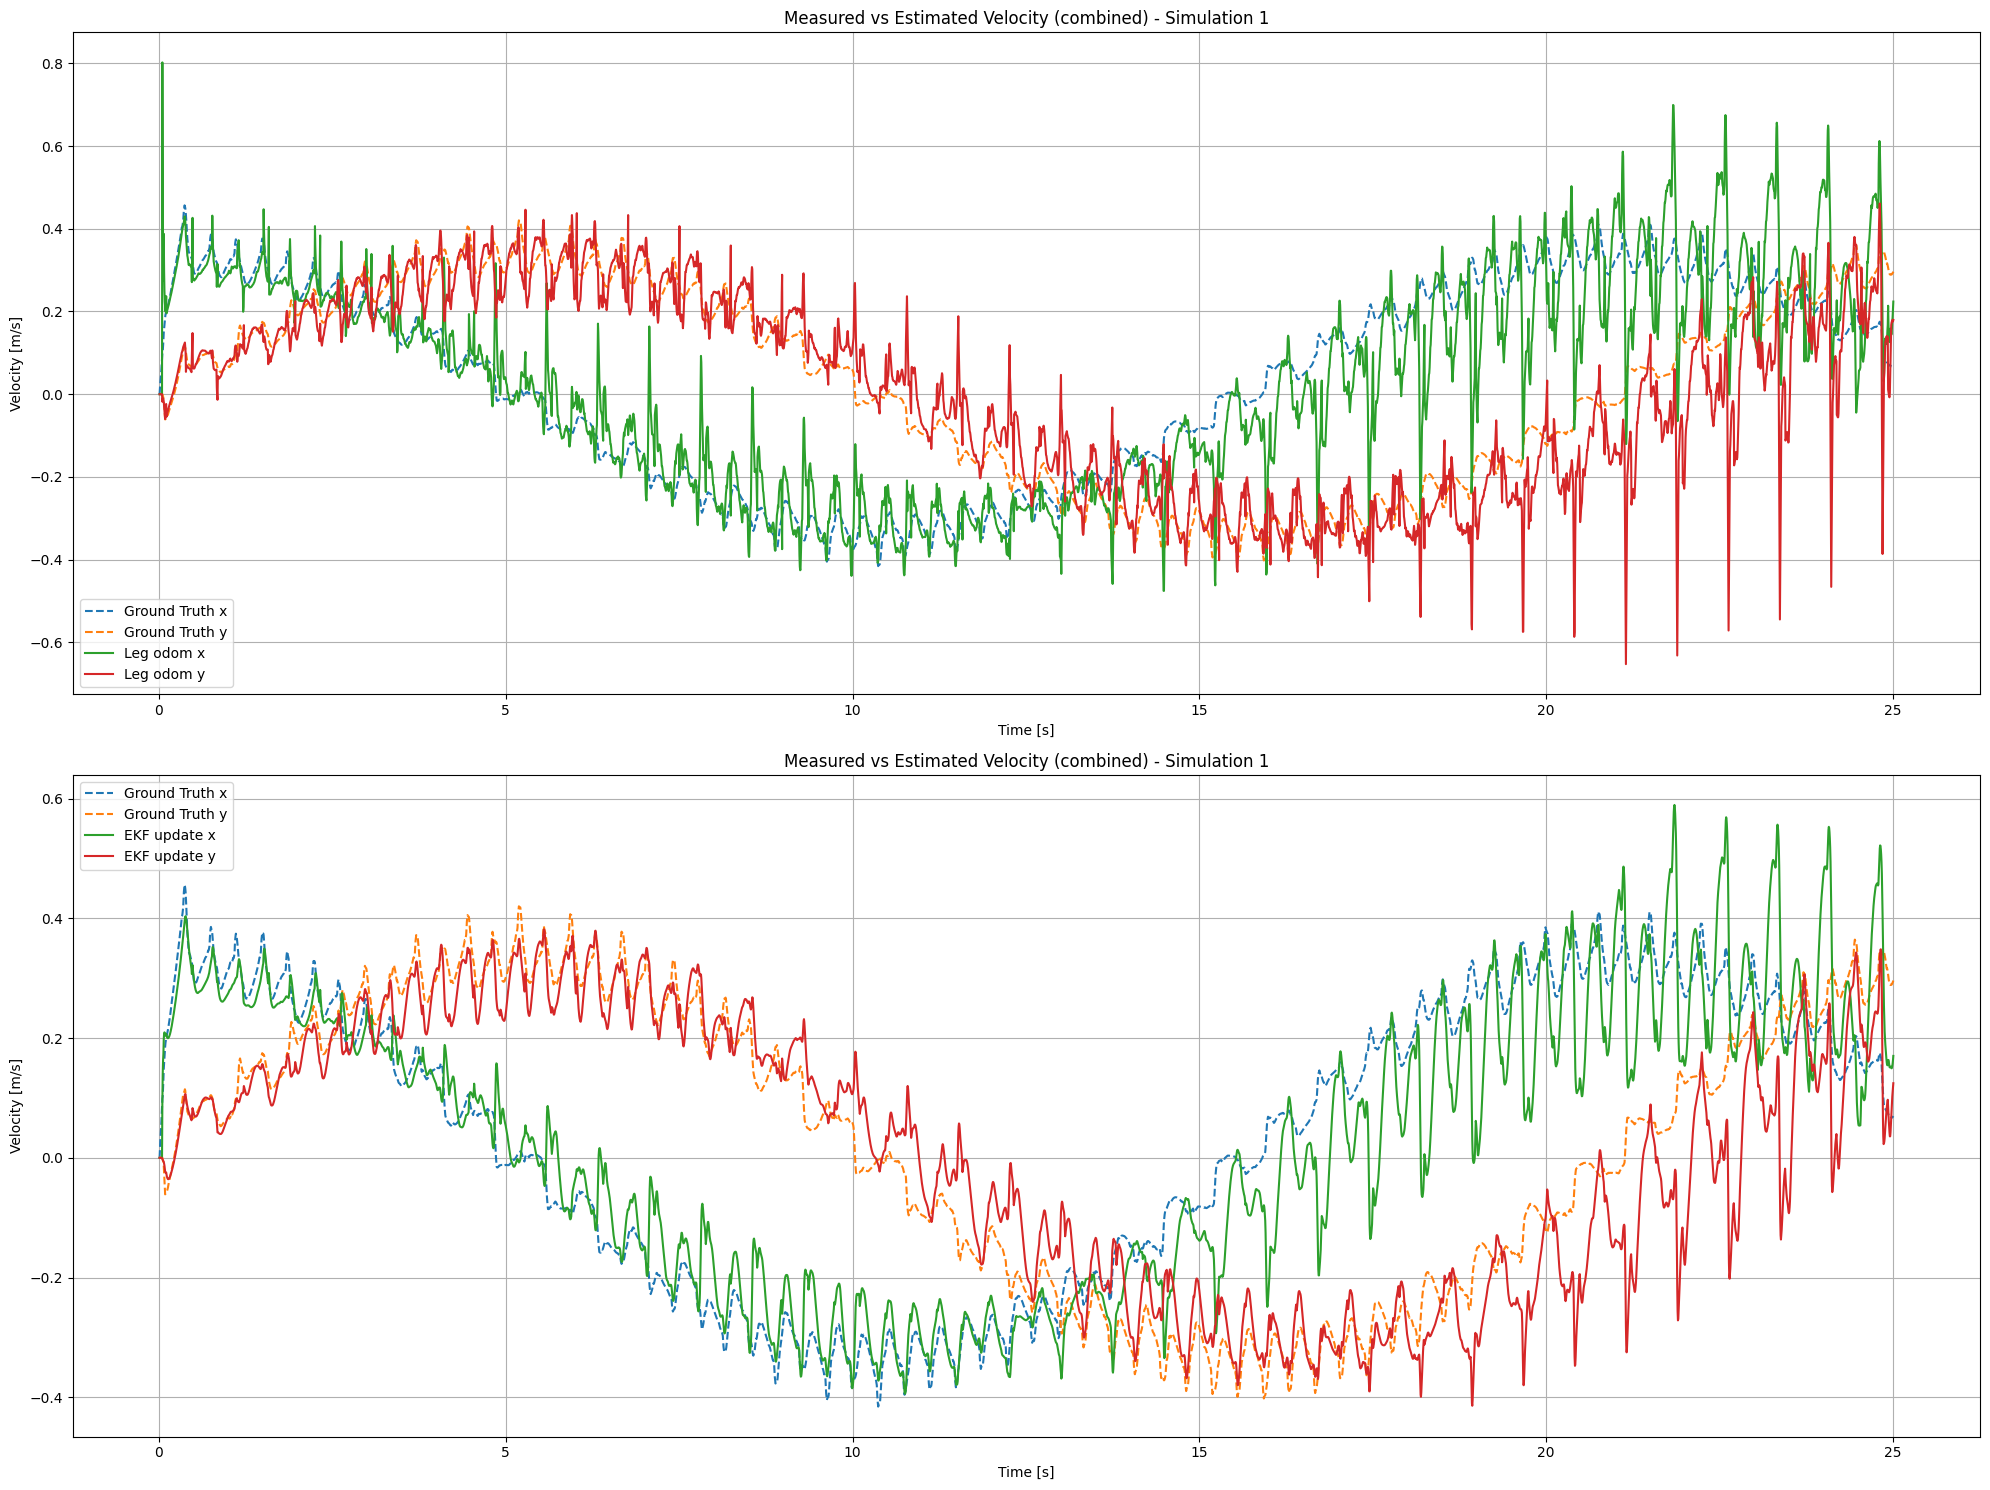

In [48]:
# --- Velocity leg odom, EKF and gt ---
predictions = [np.array(leg_odom)[sim_num][:, :2], np.array(vel_update[sim_num])[:, :2]]
pred_labels = ["Leg odom", "EKF update"]

compare_estimation_plot(time=time[sim_num],
                        gt_values=base_vel[sim_num][:, :2],
                        pred_values=predictions,
                        pred_labels=pred_labels,
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity (combined) - Simulation {sim_num+1}",
                        combined_plot=False
                        )

### With data from publicly available dataset Cerberus
https://github.com/ShuoYangRobotics/Cerberus

Interesting topics:
- **/hardware_a1/imu**: internal robot IMU (raw)
    - orientation, angular_velocity, linear acceleration (filtered)
- **/imu/data**: sensorfusion, orientation computed from gyro and acc
    - orientation, angular_velocity, linear acceleration
- **/hardware_a1/joint_foot**
    - name, position, velocity
- **/mocap_node/mocap/pose**
    -pose.position, pose.orientation

---

Not existing:
- contact_forces (maybe in joint_foot last 4 of effort)
- contact_state (can be estimated as contact_state = force > threshold)
- contact_pos 

In [49]:
def dump(obj, prefix=""):
    # sehr einfache, praktische Rekursion zum Erkunden von Feldern
    if hasattr(obj, "__dict__"):
        for k, v in vars(obj).items():
            dump(v, f"{prefix}{k}.")
    else:
        # Blattwert
        print(prefix[:-1], "=", obj)

bagpath = Path("../custom_datasets/indoor_with_ground_truth_1.bag")
typestore = get_typestore(Stores.ROS2_KILTED)

with AnyReader([bagpath]) as reader:
    print(30*"=", "Topics", 30*"=")
    topics_of_interest = []

    # read topics from .bag file
    for c in reader.connections:
        print(f"{c.topic:40s}  {c.msgtype}")
        topics_of_interest.append(c.topic)
    
    for topic_of_interest in topics_of_interest:
        conns = [c for c in reader.connections if c.topic == topic_of_interest]
        if not conns:
            raise RuntimeError(f"Topic nicht gefunden: {topic_of_interest}")

        # lies genau 1 Nachricht aus dem Topic und zeig Struktur
        for conn, t, raw in reader.messages(connections=conns):
            msg = reader.deserialize(raw, conn.msgtype)
            print(f"\n{20*"="} Example for {conn.topic} ({conn.msgtype}) {20*"="}")
            dump(msg)
            break

============================== Topics ==============================
/hardware_a1/imu                          sensor_msgs/msg/Imu
/imu/data                                 sensor_msgs/msg/Imu
/hardware_a1/joint_foot                   sensor_msgs/msg/JointState
/camera_forward/infra1/image_rect_raw     sensor_msgs/msg/Image
/camera_forward/infra2/image_rect_raw     sensor_msgs/msg/Image
/mocap_node/mocap/pose                    geometry_msgs/msg/PoseStamped

==================== Example for /hardware_a1/imu (sensor_msgs/msg/Imu) ====================
header.seq = 681
header.stamp.sec = 1641843851
header.stamp.nanosec = 934998767
header.stamp.__msgtype__ = builtin_interfaces/msg/Time
header.frame_id = 
header.__msgtype__ = std_msgs/msg/Header
orientation.x = 0.0
orientation.y = 0.0
orientation.z = 0.0
orientation.w = 0.0
orientation.__msgtype__ = geometry_msgs/msg/Quaternion
orientation_covariance = [0. 0. 0. 0. 0. 0. 0. 0. 0.]
angular_velocity.x = -0.003829742781817913
angular_velocity.

In [50]:
bagpath = Path("../custom_datasets/indoor_with_ground_truth_1.bag")
typestore = get_typestore(Stores.ROS2_KILTED)

base_pos_cerberos = [] # gt for comparison
base_orient_cerberos = []
base_ang_vel_cerberos = []
base_acc_cerberos = []
joint_pos_cerberos = []
joint_vel_cerberos = []
contact_forces_cerberos = []
contact_pos_cerberos = []

topics_of_interest = ["/hardware_a1/imu", "/imu/data", "/hardware_a1/joint_foot", "/mocap_node/mocap/pose"]

with AnyReader([bagpath], default_typestore=typestore) as reader:
    for connection, timestamp, rawdata in reader.messages():
        msg = reader.deserialize(rawdata, connection.msgtype)

        if connection.topic == '/hardware_a1/imu':
            angvel = [msg.angular_velocity.x,
                      msg.angular_velocity.y,
                      msg.angular_velocity.z]
            
            lin_acc = [msg.linear_acceleration.x,
                       msg.linear_acceleration.y,
                       msg.linear_acceleration.z,]
            
            base_ang_vel_cerberos.append(angvel)
            base_acc_cerberos.append(lin_acc)
        
        if connection.topic == "/hardware_a1/joint_foot":
            jointpos = msg.position[:12]
            contactpos = msg.position[12:]
            jointvel = msg.velocity[:12]
            jointforce = msg.effort[-4:]

            joint_pos_cerberos.append(jointpos)
            joint_vel_cerberos.append(jointvel)
            contact_forces_cerberos.append(jointforce)
            contact_pos_cerberos.append(contactpos)

        if connection.topic == "/mocap_node/mocap/pose":
            pos = [msg.pose.position.x,
                   msg.pose.position.y,
                   msg.pose.position.z]
            
            orient = [msg.pose.orientation.x,
                      msg.pose.orientation.y,
                      msg.pose.orientation.z,
                      msg.pose.orientation.w]
            
            base_pos_cerberos.append(pos)
            base_orient_cerberos.append(orient)

print(f"base_pos_cerberos: {len(base_pos_cerberos)}")
print(f"base_orient_cerberos: {len(base_orient_cerberos)}")
print(f"base_ang_vel_cerberos: {len(base_ang_vel_cerberos)}")
print(f"base_acc_cerberos: {len(base_acc_cerberos)}")
print(f"joint_pos_cerberos: {len(joint_pos_cerberos)}")
print(f"joint_vel_cerberos: {len(joint_vel_cerberos)}")
print(f"contact_forces_cerberos: {len(contact_forces_cerberos)}")
print(f"contact_pos_cerberos: {len(contact_pos_cerberos)}")

min_len = min(len(base_pos_cerberos),
              len(base_orient_cerberos),
              len(base_ang_vel_cerberos),
              len(base_acc_cerberos),
              len(joint_pos_cerberos),
              len(joint_vel_cerberos),
              len(contact_forces_cerberos),
              len(contact_pos_cerberos))

base_pos_cerberos = base_pos_cerberos[:min_len]
base_orient_cerberos = base_orient_cerberos[:min_len]
base_ang_vel_cerberos = base_ang_vel_cerberos[:min_len]
base_acc_cerberos = base_acc_cerberos[:min_len]
joint_pos_cerberos = joint_pos_cerberos[:min_len]
joint_vel_cerberos = joint_vel_cerberos[:min_len]
contact_forces_cerberos = contact_forces_cerberos[:min_len]
contact_pos_cerberos = contact_pos_cerberos[:min_len]

print(f"\nReducing data length to: {min_len}.")

base_pos_cerberos: 11052
base_orient_cerberos: 11052
base_ang_vel_cerberos: 13870
base_acc_cerberos: 13870
joint_pos_cerberos: 13869
joint_vel_cerberos: 13869
contact_forces_cerberos: 13869
contact_pos_cerberos: 13869

Reducing data length to: 11052.


In [51]:
def estimate_contact_state(contact_force, threshold=15):
    contact_force = np.array(contact_force)
    return contact_force > threshold

In [52]:
print(np.array(base_pos_cerberos[0]).shape)
print(np.array(base_orient_cerberos[0]).shape)
print(np.array(base_ang_vel_cerberos[0]).shape)
print(np.array(base_acc_cerberos[0]).shape)
print(np.array(joint_pos_cerberos[0]).shape)
print(np.array(joint_vel_cerberos[0]).shape)
print(estimate_contact_state(contact_forces_cerberos[0]).shape)
print(np.array(contact_forces_cerberos[0]).shape)
print(np.array(contact_pos_cerberos[0]).shape)

(3,)
(4,)
(3,)
(3,)
(12,)
(12,)
(4,)
(4,)
(4,)


In [53]:
Q_diag = 0.0002
R_diag = 0.01
ekf = utils.state_estimation.EKF(init_pos=base_pos_cerberos[0], dt=0.1, Q_diag=Q_diag, R_diag=R_diag)

# results of EKF prediction step
pos_predict_cerberos = []
vel_precict_cerberos = []
P_predict_cerberos = []

# results of leg odometry
leg_odom_cerberos = []

# results of EKF update step
pos_update_cerberos= []
vel_update_cerberos = []
P_update_cerberos = []

for i in tqdm(range(min_len), desc="Estimating state"):
    contact_state = estimate_contact_state(contact_forces_cerberos[i])

    ekf.step(base_orient=base_orient_cerberos[i],
             base_acc=base_acc_cerberos[i], # prediction step with base acceleration as control input
             base_ang_vel=base_ang_vel_cerberos[i],
             joint_pos=joint_pos_cerberos[i],
             joint_vel=joint_vel_cerberos[i],
             contact_states=contact_state,
             contact_forces=contact_forces_cerberos[i],
             contact_pos=contact_pos_cerberos[i])

    pos_predict_cerberos.append(ekf.x_pred[:3])
    vel_precict_cerberos.append(ekf.x_pred[3:])
    P_predict_cerberos.append(ekf.P_pred)

    leg_odom_cerberos.append(ekf.z)

    pos_update_cerberos.append(ekf.x[:3])
    vel_update_cerberos.append(ekf.x[3:])
    P_update_cerberos.append(ekf.P)

Estimating state: 100%|██████████| 11052/11052 [00:04<00:00, 2754.36it/s]


In [54]:
est_base_pos_cerberos = compute_pos_from_estimated_vel(vel_update_cerberos, 0.1)

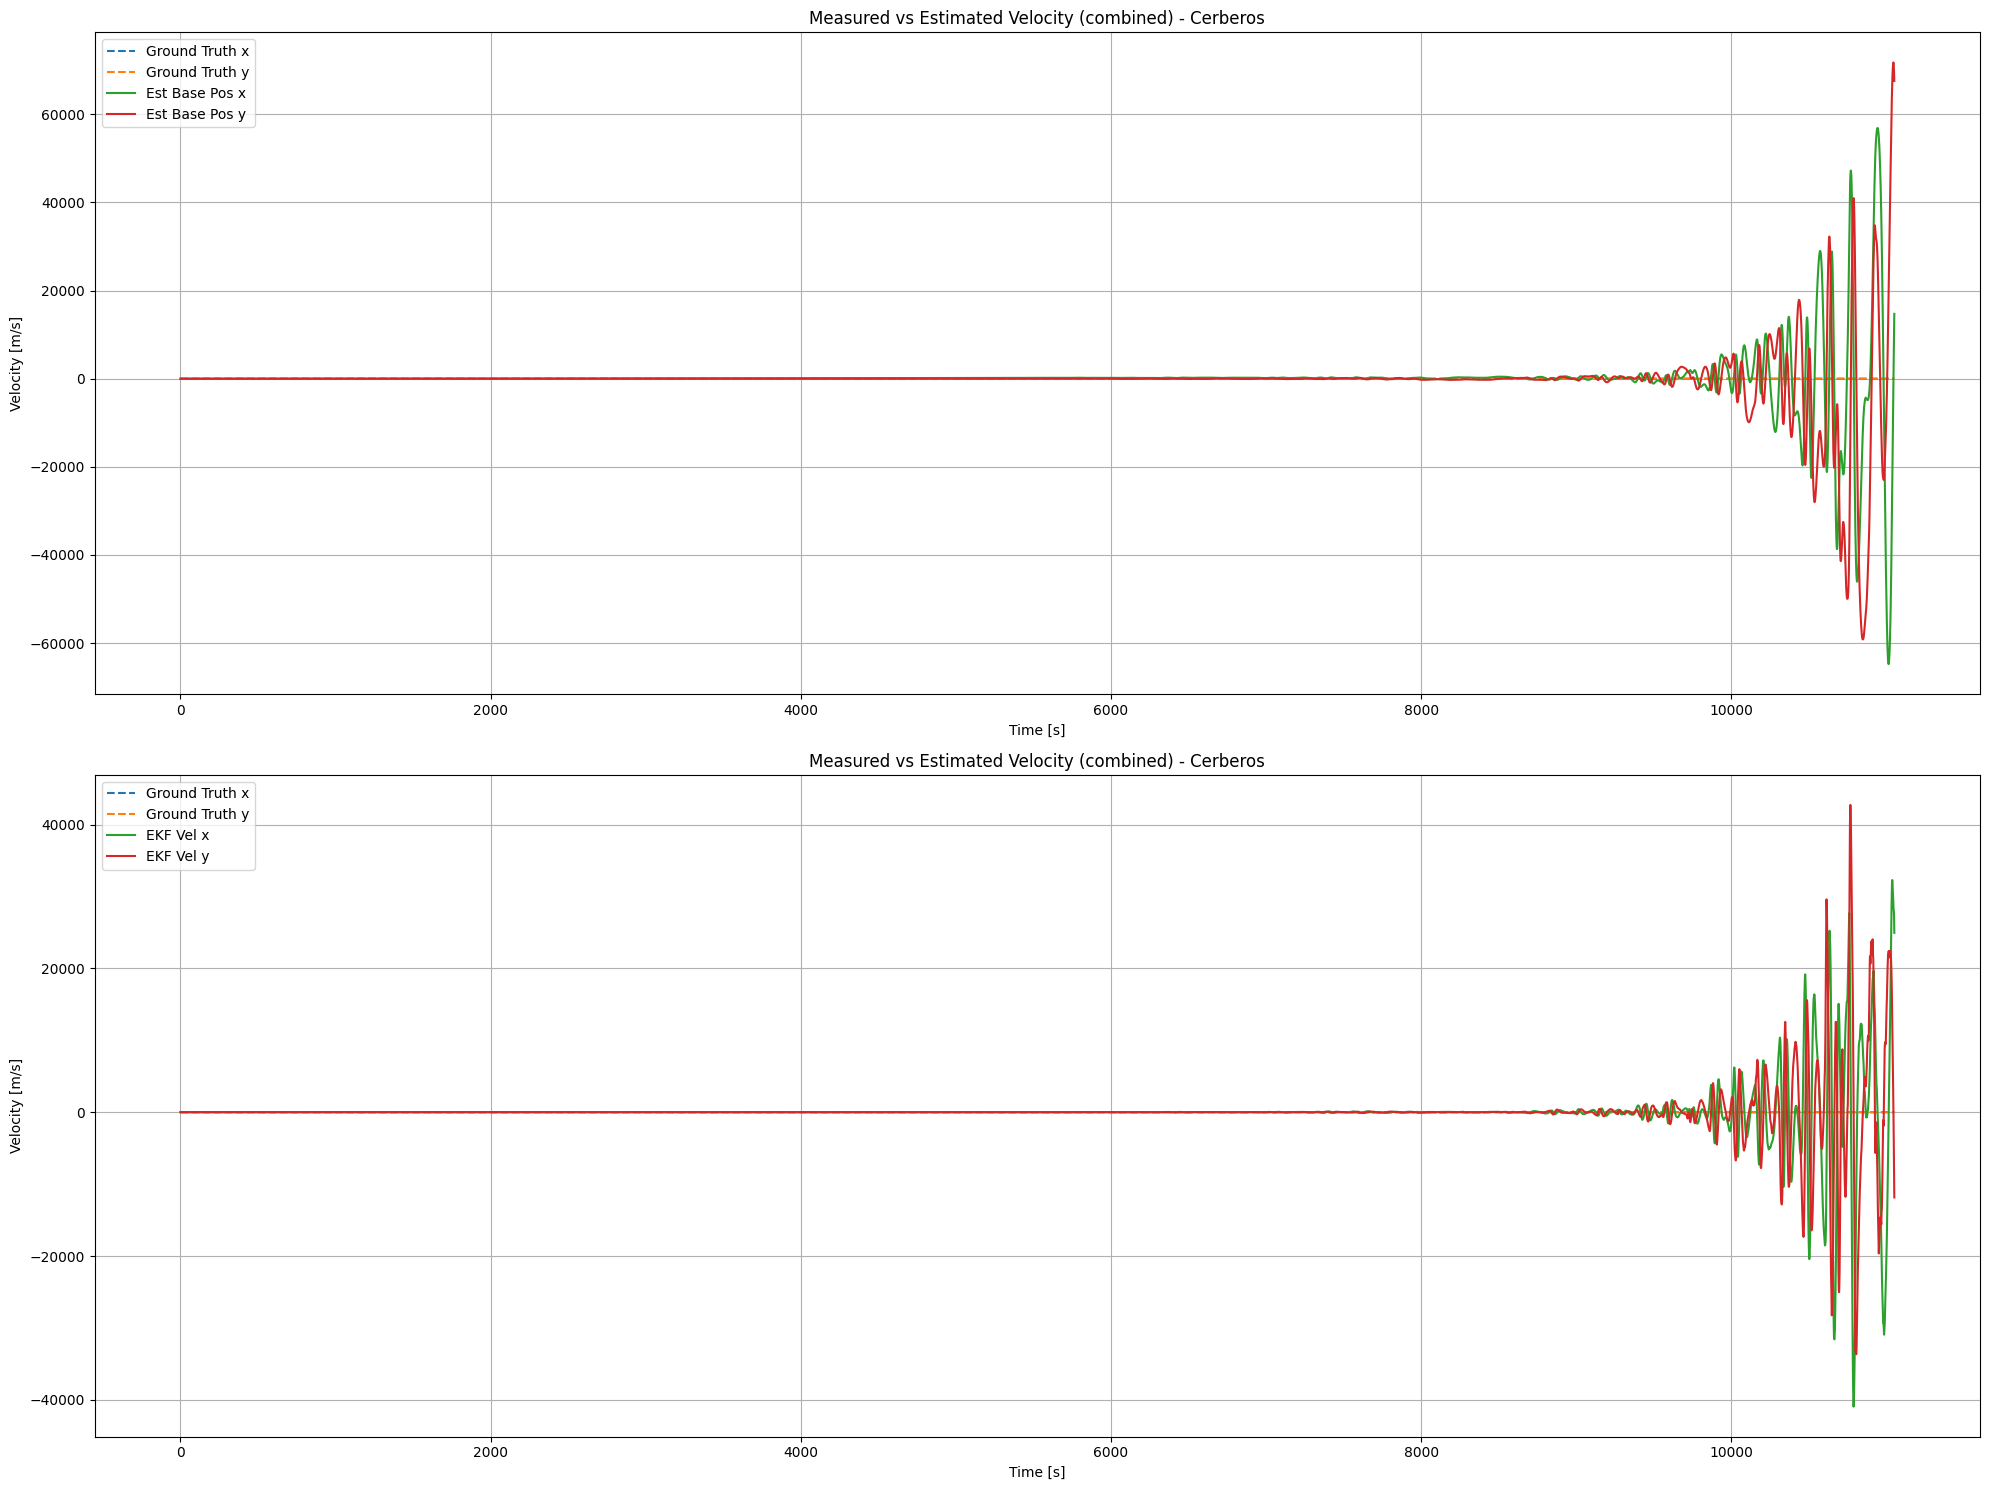

In [55]:
# --- Velocity leg odom, EKF and gt ---
predictions = [np.array(est_base_pos_cerberos)[:, :2], np.array(vel_update_cerberos)[:, :2]]
pred_labels = ["Est Base Pos", "EKF Vel"]

compare_estimation_plot(time=np.arange(min_len),
                        gt_values=np.array(base_pos_cerberos)[:, :2],
                        pred_values=predictions,
                        pred_labels=pred_labels,
                        ylabel="Velocity [m/s]",
                        title=f"Measured vs Estimated Velocity (combined) - Cerberos",
                        combined_plot=False
                        )